In [142]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt


In [143]:
df = pd.read_csv('houses.csv',usecols=['GarageQual' , 'FireplaceQu' , 'SalePrice'])

In [144]:
df.isnull().mean()*100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

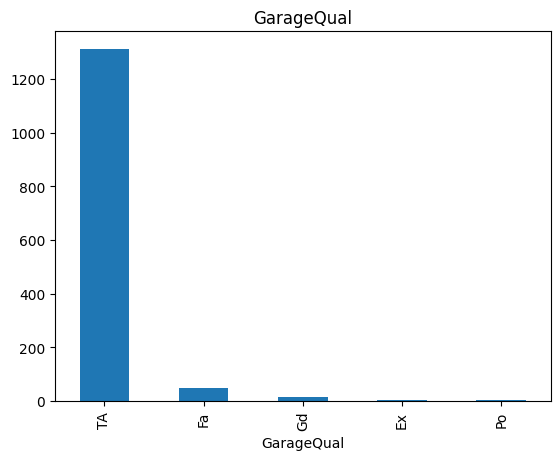

In [145]:
df['GarageQual'].value_counts(ascending=False).plot(kind='bar')
plt.title("GarageQual")
plt.show()

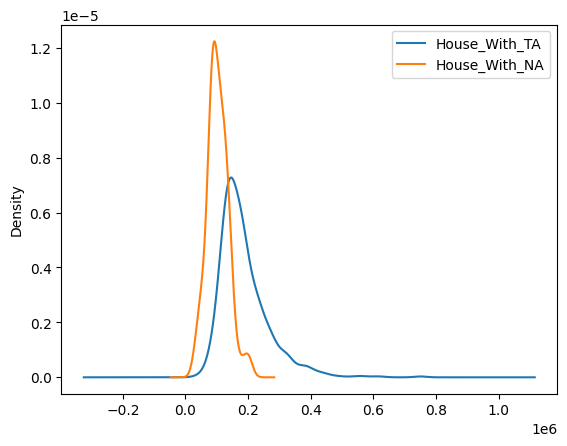

In [146]:
fig  = plt.figure()
ax = fig.add_subplot(111)

df [df['GarageQual'] == 'TA']['SalePrice'].plot(kind='kde')

df[df["GarageQual"].isnull()]['SalePrice'].plot(kind='kde')

line , labels = ax.get_legend_handles_labels()
labels = ['House_With_TA' , 'House_With_NA']
ax.legend(line , labels , loc='best')
plt.show()

In [147]:
temp = df [df['GarageQual'] == 'TA']['SalePrice']

In [148]:
df['GarageQual'] = df['GarageQual'].fillna('TA')

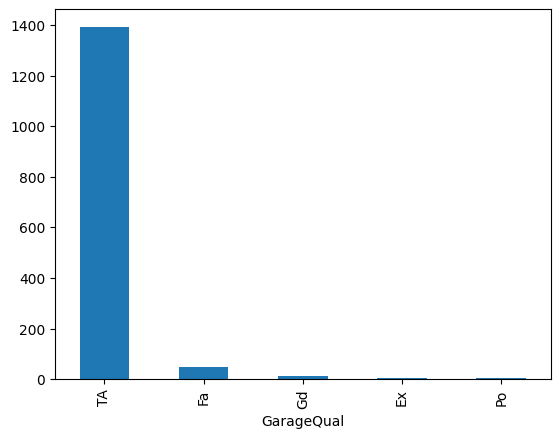

In [149]:
df['GarageQual'].value_counts(ascending=False).plot(kind= 'bar')
plt.show()

In [150]:
df

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000
...,...,...,...
1455,TA,TA,175000
1456,TA,TA,210000
1457,Gd,TA,266500
1458,NaN,TA,142125


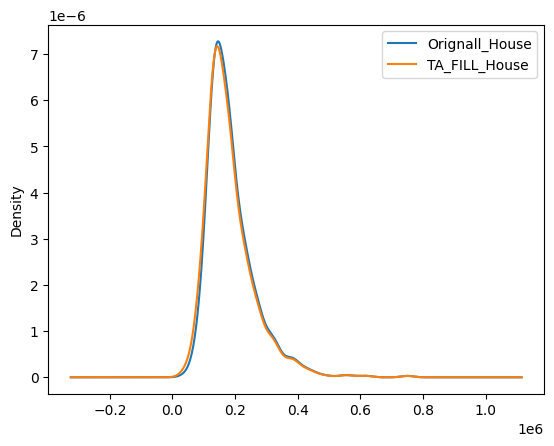

In [151]:
fig  = plt.figure()
ax = fig.add_subplot(111)

temp.plot(kind='kde')

df[df["GarageQual"]== 'TA']['SalePrice'].plot(kind='kde')

line , labels = ax.get_legend_handles_labels()
labels = ['Orignall_House' , 'TA_FILL_House']
ax.legend(line , labels , loc='best')
plt.show()

In [152]:
df['FireplaceQu'].mode()

0    Gd
Name: FireplaceQu, dtype: object

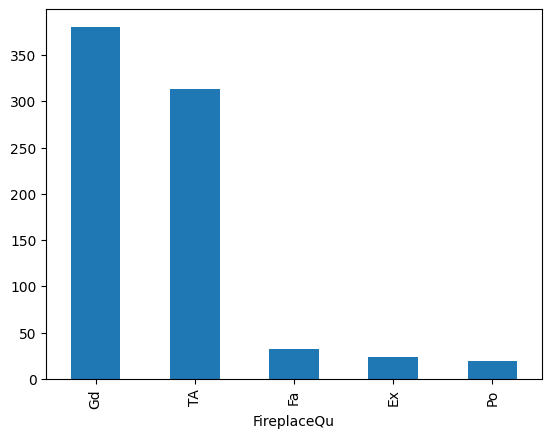

In [153]:
df['FireplaceQu'].value_counts(ascending=False).plot(kind='bar')
plt.show()

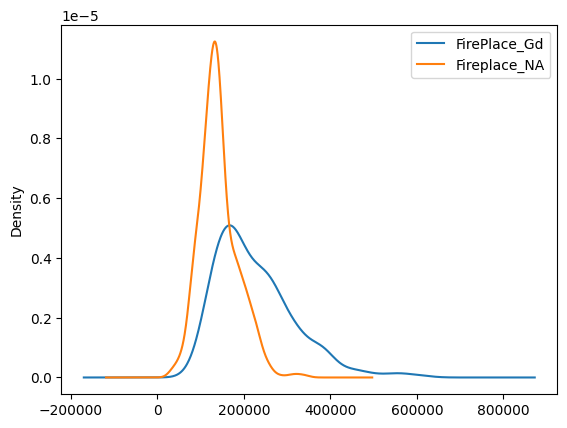

In [154]:
fig = plt.figure()
ax = fig.add_subplot(111)

df[df['FireplaceQu'] == 'Gd']['SalePrice'].plot(kind='kde')

df[df['FireplaceQu'].isnull()]['SalePrice'].plot(kind='kde')

line , labels = ax.get_legend_handles_labels()
labels = ['FirePlace_Gd' ,'Fireplace_NA']
ax.legend(line , labels , loc='best' )
plt.show()

In [155]:
temp2 = df[df['FireplaceQu'] == 'Gd']['SalePrice']

In [156]:
df['FireplaceQu'] = df['FireplaceQu'].fillna('Gd')

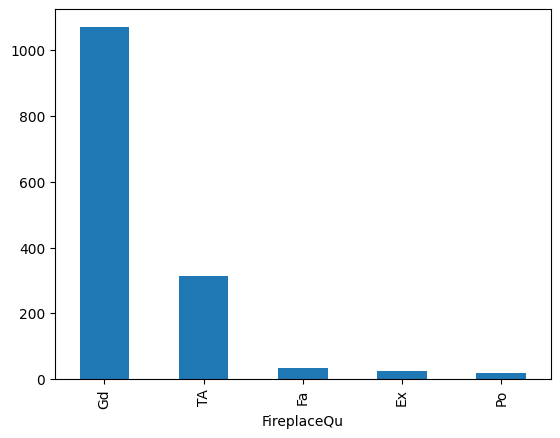

In [157]:
df['FireplaceQu'].value_counts().plot(kind='bar')
plt.show()

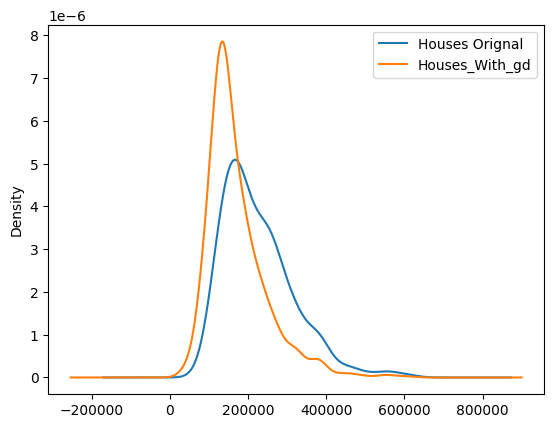

In [158]:
fig = plt.figure()
ax = fig.add_subplot(111)

temp2.plot(kind='kde')

df[df['FireplaceQu'] == 'Gd']['SalePrice'].plot(kind='kde')

lines ,labels = ax.get_legend_handles_labels()
labels = ['Houses Orignal' , 'Houses_With_gd']
ax.legend(lines , labels , loc='best')
plt.show()

# Using sklearn

In [159]:
from sklearn.model_selection import train_test_split
x_train , x_test ,y_train ,y_test =train_test_split(df.drop(columns=['SalePrice']),
                                                  df['SalePrice'],
                                                  test_size=0.2,
                                                  random_state=2)

In [160]:
from sklearn.impute import SimpleImputer

In [161]:
imputer = SimpleImputer(strategy='most_frequent')

In [162]:
x_train = imputer.fit_transform(x_train)
x_test = imputer.transform(x_test)

In [163]:
x_train = pd.DataFrame(x_train , columns = imputer.get_feature_names_out())

In [164]:
x_train

,FireplaceQu,GarageQual
0,TA,TA
1,Gd,TA
2,Fa,TA
3,Gd,TA
4,Gd,TA
...,...,...
1163,Po,TA
1164,Gd,TA
1165,Fa,TA
1166,Gd,TA


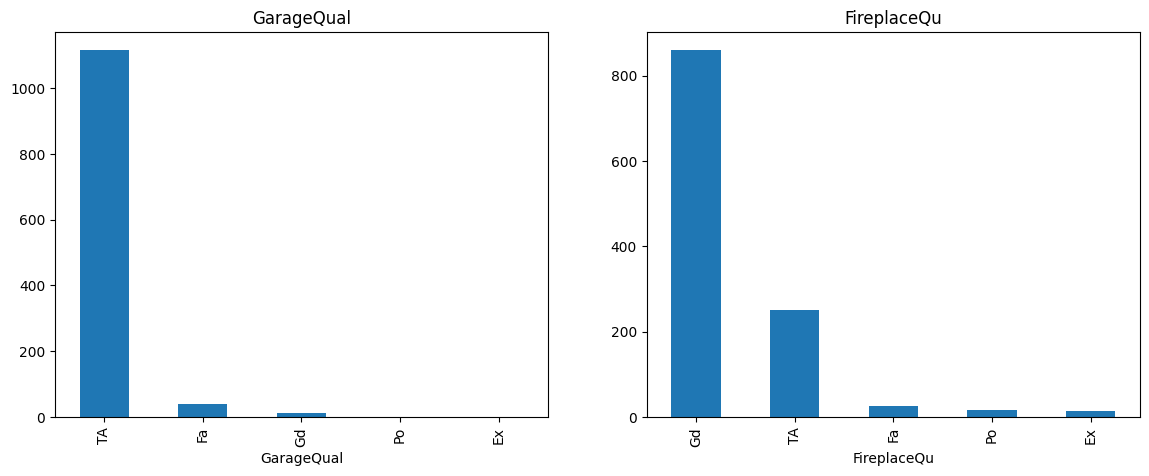

In [169]:
plt.figure(figsize=(14,5))
plt.subplot(121)
x_train['GarageQual'].value_counts().plot(kind='bar')
plt.title("GarageQual")

plt.subplot(122)
x_train['FireplaceQu'].value_counts().plot(kind='bar')
plt.title("FireplaceQu")
plt.show()

In [166]:
imputer.statistics_

array(['Gd', 'TA'], dtype=object)